### Loading the MNIST dataset

The MNIST dataset contains 10 classes representing the digits (0-9)

Link: https://keras.io/api/datasets/mnist/

In [ ]:
# Load the MNIST Dataset
from keras.datasets import mnist
import pandas as pd
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Shape of training images:", x_train.shape)
print("Shape of training labels:", y_train.shape)
print("Shape of testing images:", x_test.shape)
print("Shape of testing labels:", y_test.shape)

Shape of training images: (60000, 28, 28)
Shape of training labels: (60000,)
Shape of testing images: (10000, 28, 28)
Shape of testing labels: (10000,)


#### Load the images into data matrices

In [ ]:
import numpy as np

# Reshape training data
x_train = x_train.reshape(x_train.shape[0], -1)
y_train = y_train.reshape(y_train.shape[0], -1)

# Build data matrix by np.vstack function
X = np.vstack(x_train)
print(X.shape)

(60000, 784)


### Normalize the Data Appropriately

In [ ]:
X = X.astype('float32')/255
print(X)

y = y_train.astype('float32')
print(y)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[5.]
 [0.]
 [4.]
 ...
 [5.]
 [6.]
 [8.]]


### Data Masking

In [ ]:
# Get target digits, create boolean mask
mask_labels = [0, 3, 7]
mask = np.isin(y.flatten(), mask_labels)

print(mask)

X_filtered = X[mask, :]
y_filtered = y[mask]

# Count occurrences of each label in the masked data.
unique_labels, counts = np.unique(y_filtered, return_counts=True)

# Display the results
print("Labels:", unique_labels)
print("Counts:", counts)

print("Shape of filtered images:", X_filtered.shape)
print("Shape of filtered labels:", y_filtered.shape)

[False  True False ... False False False]
Labels: [0. 3. 7.]
Counts: [5923 6131 6265]
Shape of filtered images: (18319, 784)
Shape of filtered labels: (18319, 1)


### K Deep Simplex Playground

Motivating Question: Can we do a better job with separating our data appropriately into the respective clusters? How can we learn the
coefficient matrix 'A' and sparse matrix 'X' so that we can appromixate
the data appropriately?

Paper of Reference by Professor Dr. Abiy Tasissa: https://arxiv.org/pdf/2012.02134v4

### Generate Synthetic Images with K Deep Simplex

In [ ]:
# Github Project: https://github.com/abiy-tasissa/K-Deep-Simplex-KDS-algorithm
'''
Define the model that finds a sparse representation x for the input data y
using an iterative process involving the weight matrix W. The goal is to
the learn the following:

- W: Weight matrix
- X: Sparse matrix that learns the sparse representation of Y

Y = A*X
'''
import torch
import torch.nn as nn
import torch.nn.functional as F

class KDS(nn.Module):
    def __init__(
        self,
        num_layers,
        input_size, # Training data
        hidden_size, # Number of archetypes, atoms.
        penalty, # Locality penalty.
        accelerate=True,
        train_step=True,
        W=None, # The dictionary containing the archetypes.
        step=None,
    ):
        super(KDS, self).__init__()

        # hyperparameters
        self.register_buffer("num_layers", torch.tensor(int(num_layers)))
        self.register_buffer("input_size", torch.tensor(int(input_size)))
        self.register_buffer("hidden_size", torch.tensor(int(hidden_size)))
        self.register_buffer("penalty", torch.tensor(float(penalty)))
        self.register_buffer("accelerate", torch.tensor(bool(accelerate)))

        # parameters
        if W is None:
            W = torch.zeros(self.hidden_size, self.input_size)

        self.register_parameter("W", torch.nn.Parameter(W))
        if step is None:
            step = W.svd().S[0] ** -2
        if train_step:
            self.register_parameter("step", torch.nn.Parameter(step))
        else:
            self.register_buffer("step", step)

    '''
    For each data point y, encode y into the sparse representation, take the sparse representation
    and compute the y_hat (approximation of y)
    '''
    def forward(self, y):
        x = self.encode(y)
        y = self.decode(x)
        return y

    # Calculates the sparse codes.
    def encode(self, y):
        if self.accelerate:
            return self.encode_accelerated(y)
        else:
            return self.encode_basic(y)

    # No accelerated gradient descent.
    def encode_basic(self, y):
        x = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        # weight = (y.unsqueeze(1) - self.W.unsqueeze(0)).pow(2).sum(dim=2)
        weight = (
            y.square().sum(dim=1, keepdims=True)
            + self.W.T.square().sum(dim=0, keepdims=True)
            - 2 * y @ self.W.T
        )
        for layer in range(self.num_layers):
            grad = (x @ self.W - y) @ self.W.T
            grad = grad + weight * self.penalty
            x = self.activate(x - grad * self.step)
        return x

    # Encode the sparse metrics with accelerated gradient descent.
    def encode_accelerated(self, y):
        x_tmp = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        x_old = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        # weight = (y.unsqueeze(1) - self.W.unsqueeze(0)).pow(2).sum(dim=2)
        weight = (
            y.square().sum(dim=1, keepdims=True)
            + self.W.T.square().sum(dim=0, keepdims=True)
            - 2 * y @ self.W.T
        )
        for layer in range(self.num_layers):
            grad = (x_tmp @ self.W - y) @ self.W.T
            grad = grad + weight * self.penalty
            x_new = self.activate(x_tmp - grad * self.step)
            x_old, x_tmp = x_new, x_new + layer / (layer + 3) * (x_new - x_old)
        return x_new

    # Compute the y_hat with the sparse matrix and learned dictionary.
    def decode(self, x):
        return x @ self.W

    def activate(self, x):
        m, n = x.shape
        cnt_m = torch.arange(m, device=x.device)
        cnt_n = torch.arange(n, device=x.device)
        u = x.sort(dim=1, descending=True).values
        v = (u.cumsum(dim=1) - 1) / (cnt_n + 1)
        w = v[cnt_m, (u > v).sum(dim=1) - 1]
        return (x - w.view(m, 1)).relu()

In [ ]:
# Loss
class LocalDictionaryLoss(torch.nn.Module):
    def __init__(self, penalty):
        super(LocalDictionaryLoss, self).__init__()
        self.penalty = penalty

    def forward(self, A, y, x):
        return self.forward_detailed(A, y, x)[2]

    def forward_detailed(self, A, y, x):
        weight = (y.unsqueeze(1) - A.unsqueeze(0)).pow(2).sum(dim=2)
        a = 0.5 * (y - x @ A).pow(2).sum(dim=1).mean()
        b = (weight * x).sum(dim=1).mean()
        return a, b, a + b * self.penalty

In [ ]:
def get_mnist_data():
  (x_train, y_train), (x_test, y_test) = mnist.load_data()
  x_all = np.concatenate([x_train, x_test])
  y_all = np.concatenate([y_train, y_test])
  x_all = x_all.reshape(x_all.shape[0], 784).astype(float) / 255.0
  return x_all, y_all

def get_mnist_train_data():
  (x_train, y_train), (x_test, y_test) = mnist.load_data()
  x_train = x_train.reshape(x_train.shape[0], 784).astype(float) / 255.0
  return x_train, y_train

def prune(data, labels, wanted):
    n = len(data)
    idx = [i for i in range(n) if labels[i] in wanted]
    data = data[idx]
    labels = labels[idx]
    lookup = np.arange(int(labels.max() + 1))
    lookup[wanted] = np.arange(len(wanted))
    labels = lookup[labels]
    return data, labels

data, labels = get_mnist_train_data()
data, labels = prune(data, labels, [0, 3, 7])
data /= np.linalg.norm(data, axis=1, keepdims=True)
data = torch.tensor(data).float()
labels = torch.tensor(labels)

#### Model Training If Not Done Previously


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader
import random
import tensorflow as tf
import numpy as np
from tqdm import tqdm as progress_bar

'''
Steps:
- Convert the filtered data to PyTorch tensors.
- Instantiate the KDS model with the model parameters.
- Define the loss function and optimizer.
- Train the KDS model.
'''

# Instantiate the KDS model
input_size = X_filtered.shape[1]
hidden_size = 100 # This can be tuned, num of columns in dictionary A.
num_layers = 75 # This can be tuned
penalty = 0.25 # Reduced penalty slightly
learning_rate = 1e-3 # Further reduced learning rate

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42) # Set torch seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = KDS(
    num_layers=num_layers,
    input_size=input_size,
    hidden_size=hidden_size,
    penalty=penalty,
    accelerate=True,
    train_step=False
)

# Define loss function and optimizer
criterion = LocalDictionaryLoss(penalty=penalty)
optimizer = optim.Adam(net.parameters(), lr=learning_rate) # Adam optimizer
num_epochs = 100 # This can be tuned
clip_value = 1e-4  # Adjusted gradient clipping value
batch_size=1024

with torch.no_grad():
    p = torch.randperm(len(data))[: net.hidden_size]
    net.W.data = data[p]
    net.step.fill_((net.W.data.svd()[1][0] ** -2).item())
net = net.to(device)

for epoch in progress_bar(range(num_epochs)):
    shuffle = torch.randperm(len(data))
    data, labels = data[shuffle], labels[shuffle]
    for i in progress_bar(range(0, len(data), batch_size), disable=True):
        y = data[i : i + batch_size].to(device)
        x_hat = net.encode(y)
        loss = criterion(net.W, y, x_hat)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), clip_value)
        optimizer.step()

    if epoch + 1 % 10 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")

print("Training finished.")


100%|██████████| 100/100 [1:26:50<00:00, 52.11s/it]

Training finished.


In [ ]:
import os

# Define the base path again to ensure it's correct
base_path = '/content/drive/My Drive/Tufts/Masters Thesis Research/Synthetic_Data_Interpolation'

# Check if the directory exists
if os.path.exists(base_path):
    print(f"Directory '{base_path}' exists.")
    print("Contents of the directory:")
    for item in os.listdir(base_path):
        print(f"- {item}")
else:
    print(f"Directory '{base_path}' DOES NOT exist. Please ensure the path is correct and your Drive is mounted properly.")


Directory '/content/drive/My Drive/Tufts/Masters Thesis Research/Synthetic_Data_Interpolation' exists.
Contents of the directory:
- kds_model.pth
- atoms.pth
- sparse_codes.pth


In [ ]:
import os

# Correct the path to include /content/drive/
base_path = '/content/drive/My Drive/Tufts/Masters Thesis Research/Synthetic_Data_Interpolation'
file_name = 'kds_model.pth'
path = os.path.join(base_path, file_name)

# Create the directory if it does not exist
os.makedirs(base_path, exist_ok=True)

torch.save(net.state_dict(), path)

### Reviewing the KDS Paper for Implementation Details

To help debug the NaN loss issue and ensure the PyTorch implementation aligns with the KDS algorithm, focus on these key areas in the paper (https://arxiv.org/pdf/2012.02134v4):

*   **Section 3: K-Deep Simplex (KDS)**: This section should contain the core algorithm description. Pay close attention to:
    *   The objective function being minimized.
    *   The iterative update rules for both the sparse representation **X** and the dictionary **A** (which corresponds to **W** in the code).
    *   The specific projection step used in the algorithm (the `activate` function in the code). Ensure the implementation accurately reflects this projection.
    *   Any details on the convergence properties or conditions for stability.

*   **Algorithm Box**: If the paper includes a pseudocode or algorithm box, study it carefully. Compare each step in the pseudocode with the corresponding lines of code in the `KDS` class, especially within the `encode_basic` and `encode_accelerated` methods.

*   **Initialization**: Look for details on how the initial weight matrix **W** (or dictionary **A**) and the step size are initialized. Incorrect initialization can sometimes lead to training instability.

*   **Convergence Criteria**: Understand how the algorithm is supposed to converge. While the current training loop uses a fixed number of epochs, the paper might describe convergence criteria based on the change in the objective function or the parameters.

*   **Regularization**: Review the role of the penalty term (`penalty` in the code) and how it affects the optimization. Ensure the penalty term is applied correctly in the gradient calculations.

By carefully examining these sections, you can compare the implementation in the notebook with the algorithm described in the paper and identify any discrepancies that might be causing the instability.

Now that the KDS model is trained, we can use it to generate synthetic images.

#### Model Loading Functionality Before Hand

In [ ]:
import torch

model_path = '/content/drive/My Drive/Tufts/Masters Thesis Research/Synthetic_Data_Interpolation/kds_model.pth'

# Instantiate the KDS model first, with the same architecture as trained
# (These parameters must match the ones used during training)
input_size = X_filtered.shape[1]
hidden_size = 100 # This can be tuned, num of columns in dictionary A.
num_layers = 75 # This can be tuned
penalty = 0.25 # Reduced penalty slightly
learning_rate = 1e-3 # Further reduced learning rate

net = KDS(
    num_layers=num_layers,
    input_size=input_size,
    hidden_size=hidden_size,
    penalty=penalty,
    accelerate=True,
    train_step=True
)

# Load the state dictionary into the instantiated model
net.load_state_dict(torch.load(model_path))

# Move the model to the device (e.g., GPU if available) if it was trained on it
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = net.to(device)

# Set the model to evaluation mode
#net.eval()

### KDS Image Reconstruction

Shape of KDS reconstructed images: (18319, 784)


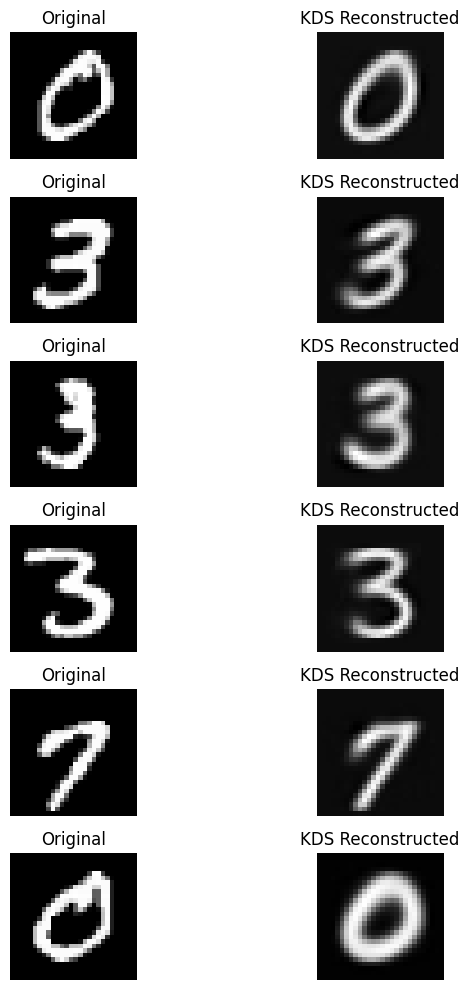

In [ ]:
# Generate synthetic images using the trained KDS model
# We can pass the original filtered data through the trained model
import torch
import matplotlib.pyplot as plt

n_images_to_display = 6  # Number of images to display

# Convert X_filtered to a PyTorch tensor before passing it to the model
X_filtered_tensor = torch.from_numpy(X_filtered).float()

X_kds_reconstructed = net(X_filtered_tensor).detach().numpy()

print("Shape of KDS reconstructed images:", X_kds_reconstructed.shape)

# Reshape reconstructed data back to image dimensions for visualization
X_kds_reconstructed_images = X_kds_reconstructed.reshape(-1, 28, 28)

# Display some original and KDS reconstructed images
fig, axes = plt.subplots(n_images_to_display, 2, figsize=(8, 10))

for i in range(n_images_to_display):
    # Original image (need to convert back to numpy for matplotlib if X_filtered was modified)
    # Assuming X_filtered is still the original numpy array from previous cells
    axes[i, 0].imshow(X_filtered[i].reshape(28, 28), cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    # KDS reconstructed image
    axes[i, 1].imshow(X_kds_reconstructed_images[i], cmap='gray')
    axes[i, 1].set_title("KDS Reconstructed")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Check the sparse codes. # Achieved valid sparse codes.
sample_idx = 0
sample = data[sample_idx:sample_idx+1]

sparse_codes = net.encode(sample.to(device))
print(f'Sparse Codes size {sparse_codes.size}')
print(f'Non-zero elements {(sparse_codes > 1e-6).sum().item()}')
print(f'Sparsity Ratio {(sparse_codes < 1e-6).sum().item() / sparse_codes.numel() * 100:.2f}%')
print(f'Codes sum to 1 {sparse_codes.sum(dim=1).item():.4f}')

Sparse Codes size <built-in method size of Tensor object at 0x78008a5e4b40>
Non-zero elements 4
Sparsity Ratio 96.00%
Codes sum to 1 1.0000


### Setup Graph Structure

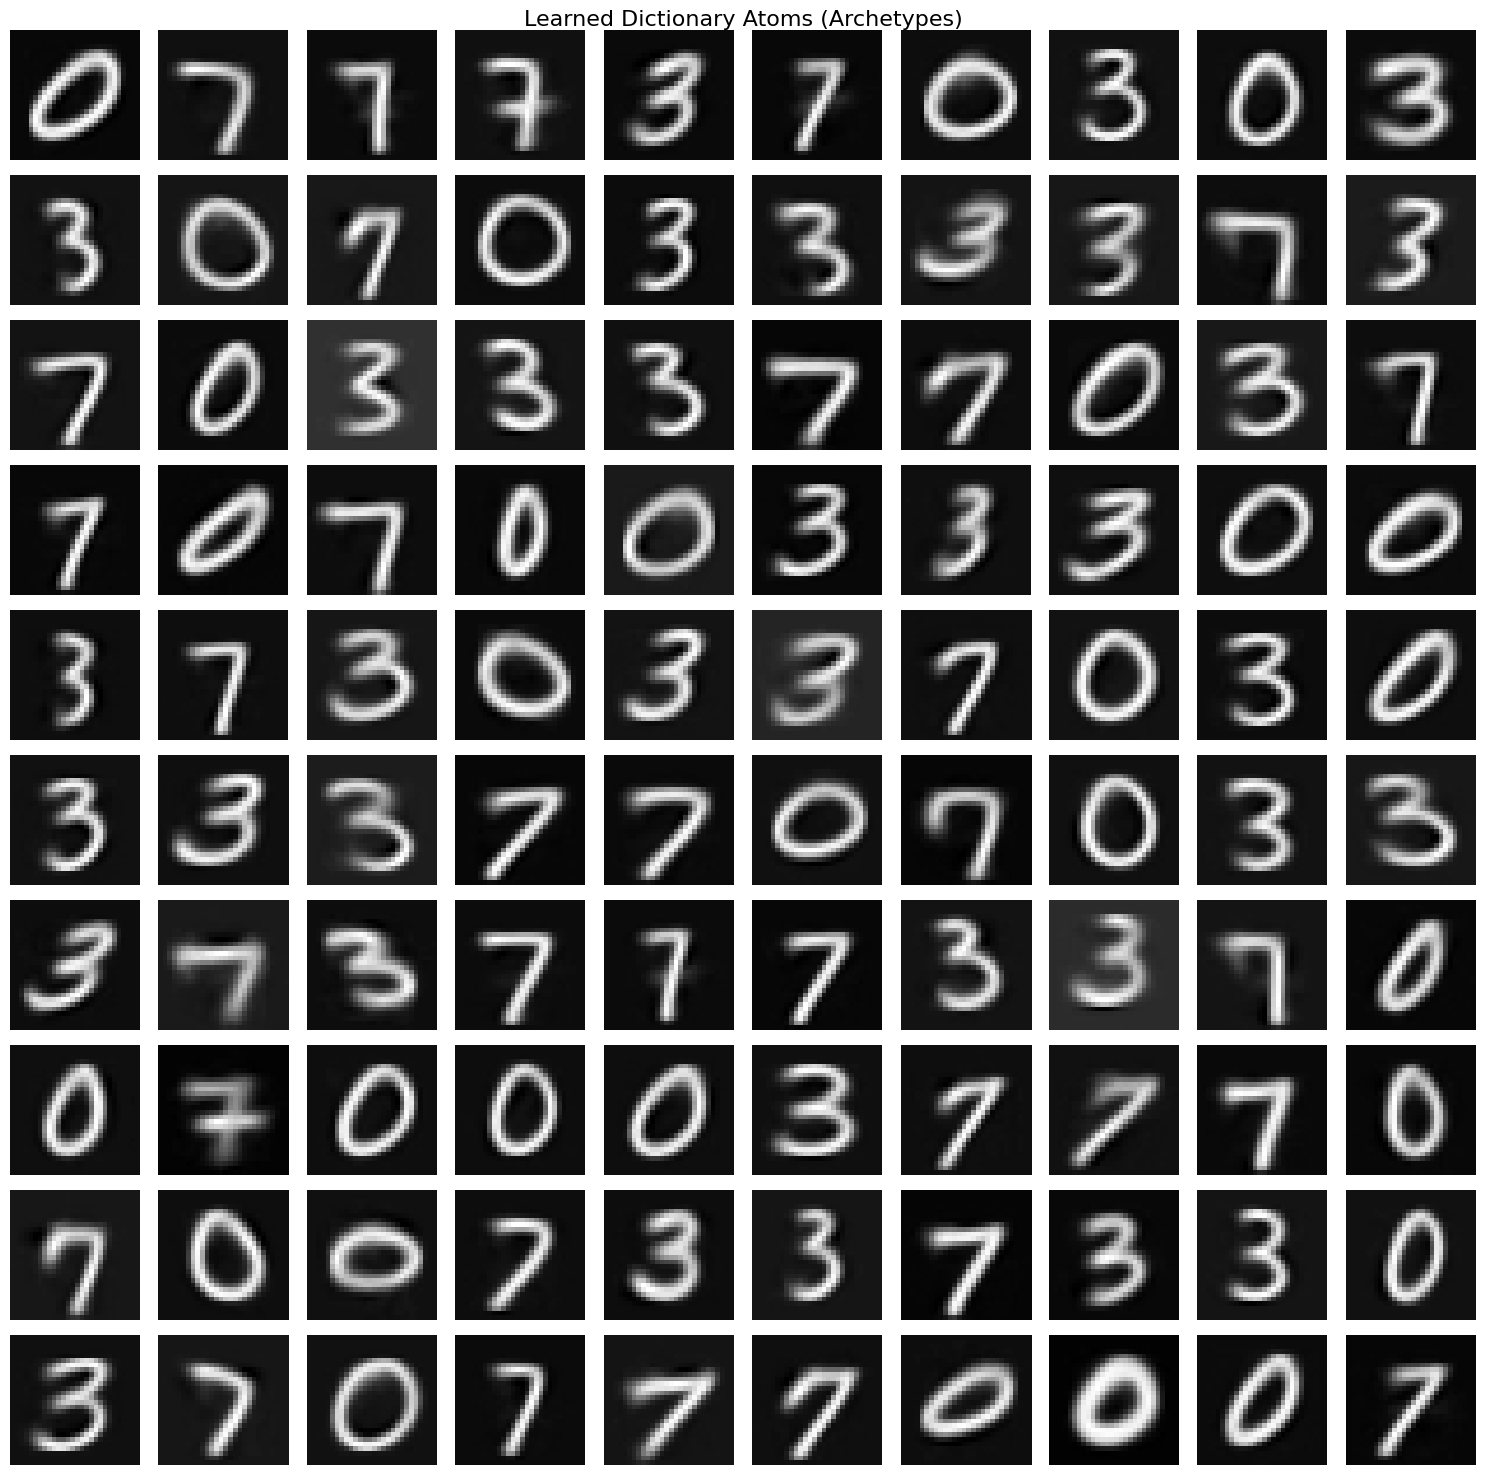

In [ ]:
# Step 1: Visualize the learned atoms
import os
import matplotlib.pyplot as plt

file_name = 'atoms.pth'
atoms_path = os.path.join(base_path, file_name)

# Create the directory if it does not exist
os.makedirs(base_path, exist_ok=True)

fig, axes = plt.subplots(10, 10, figsize=(15, 15))
with torch.no_grad():
  atoms = net.W.cpu().numpy() # Extract the learned archetype dictionary
  torch.save(atoms, atoms_path)

for i, ax in enumerate(axes.flat): # Go through each row of subplots in the 10*10 figure of subplots
  if i < len(atoms):
    atom = atoms[i] # Extract the current atom
    ax.imshow(atom.reshape(28, 28), cmap='gray') # Display it on the current axis
  ax.axis('off')

plt.suptitle('Learned Dictionary Atoms (Archetypes)', fontsize = 16)
plt.tight_layout()
plt.show()

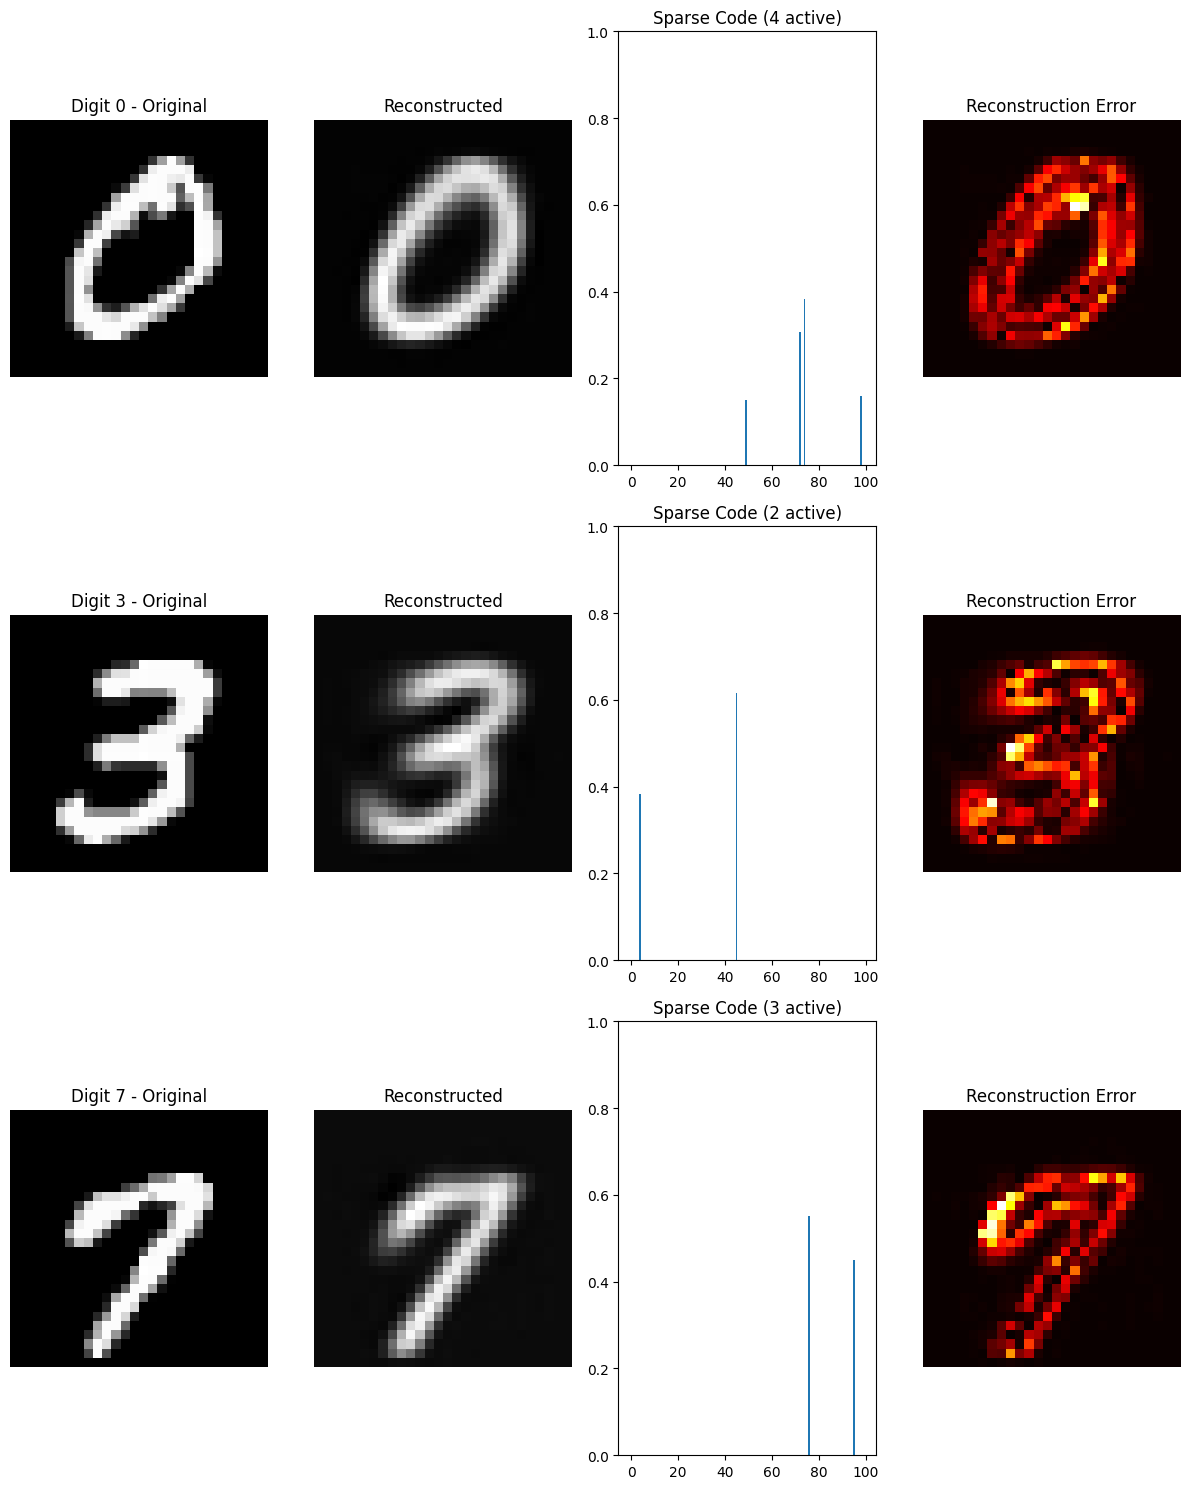

In [ ]:
# Analyzing the reconstruction quality of each digit class.
fig, axes = plt.subplots(3, 4, figsize=(12, 15)) # 4 columns to highlight the original, reconstructed, sparse codes, and difference

for digit_idx, digit in enumerate([0, 3, 7]):
    indices = np.where(y_filtered == digit)[0]
    sample_idx = indices[0] # Extract the data point label where it matches the digit specified on the mask.

    original = data[sample_idx:sample_idx+1] # Get original data point
    with torch.no_grad(): # original data point with no gradients affecting the encoding step.
        reconstructed = net(original.to(device))

    # Original
    axes[digit_idx, 0].imshow(original[0].cpu().reshape(28, 28), cmap='gray')
    axes[digit_idx, 0].set_title(f'Digit {digit} - Original')
    axes[digit_idx, 0].axis('off')

    # Reconstructed
    axes[digit_idx, 1].imshow(reconstructed[0].cpu().reshape(28, 28), cmap='gray')
    axes[digit_idx, 1].set_title('Reconstructed')
    axes[digit_idx, 1].axis('off')

    # Sparse code visualization
    sparse = net.encode(original.to(device))
    axes[digit_idx, 2].bar(range(len(sparse[0])), sparse[0].detach().numpy())
    axes[digit_idx, 2].set_title(f'Sparse Code ({(sparse>1e-6).sum().item()} active)')
    axes[digit_idx, 2].set_ylim([0, 1])

    # Difference
    diff = (original[0] - reconstructed[0]).abs().cpu().reshape(28, 28)
    axes[digit_idx, 3].imshow(diff, cmap='hot')
    axes[digit_idx, 3].set_title('Reconstruction Error')
    axes[digit_idx, 3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Compute the Sparse Codes for all the data
  # Go through the batches of the data
  # Encode the batch of data
  # Save the sparse codes when you are done.

batch_size = 100

def compute_sparse_codes(model, data, batch_size=200):
  sparse_codes = []
  with torch.no_grad():
    for i in range(0, len(data), batch_size):
      sparse_code = model.encode(data[i:i+batch_size].to(device))
      sparse_codes.append(sparse_code)

  return torch.cat(sparse_codes, dim=0)

sparse_codes = compute_sparse_codes(net, data, batch_size)
print(sparse_codes)

# Analyze sparse code statistics
print(f"\nSparse Code Statistics:")
print(f"Shape: {sparse_codes.shape}")
print(f"Mean sparsity: {(sparse_codes < 1e-6).sum().item() / sparse_codes.numel() * 100:.2f}%")
print(f"Mean active atoms: {(sparse_codes > 1e-6).sum(axis=1).float().mean():.2f}")
print(f"Code sum mean: {sparse_codes.sum(axis=1).mean():.4f}")
print(f"Code sum std: {sparse_codes.sum(axis=1).std():.4f}")

# Save the Sparse Codes
file_name = 'sparse_codes.pth'
sparse_codes_path = os.path.join(base_path, file_name)

# Create the directory if it does not exist
os.makedirs(base_path, exist_ok=True)

torch.save(sparse_codes, sparse_codes_path)

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.1589, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.5835, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])

Sparse Code Statistics:
Shape: torch.Size([18319, 100])
Mean sparsity: 96.65%
Mean active atoms: 3.35
Code sum mean: 1.0000
Code sum std: 0.0000


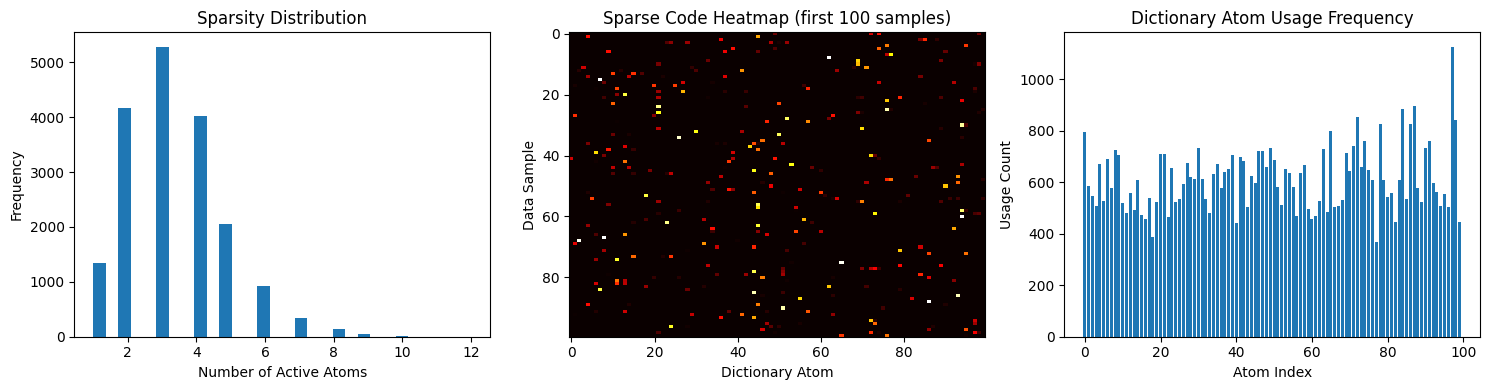

In [ ]:
# Visualize sparsity pattern
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of sparsity levels
sparsity_per_sample = (sparse_codes > 1e-6).sum(axis=1)
axes[0].hist(sparsity_per_sample, bins=30)
axes[0].set_xlabel('Number of Active Atoms')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sparsity Distribution')

# Heatmap of sparse codes (sample)
axes[1].imshow(sparse_codes[:100], aspect='auto', cmap='hot')
axes[1].set_xlabel('Dictionary Atom')
axes[1].set_ylabel('Data Sample')
axes[1].set_title('Sparse Code Heatmap (first 100 samples)')

# Atom usage frequency
atom_usage = (sparse_codes > 1e-6).sum(axis=0)
axes[2].bar(range(len(atom_usage)), atom_usage)
axes[2].set_xlabel('Atom Index')
axes[2].set_ylabel('Usage Count')
axes[2].set_title('Dictionary Atom Usage Frequency')

plt.tight_layout()
plt.show()

### Loading sparse codes and atoms

In [ ]:
atoms = torch.load(atoms_path, weights_only=False)
sparse_codes = torch.load(sparse_codes_path, weights_only=False)

### Initial Graph Building

Number of nodes in the graph: 100
Example node 0 data: (784,)


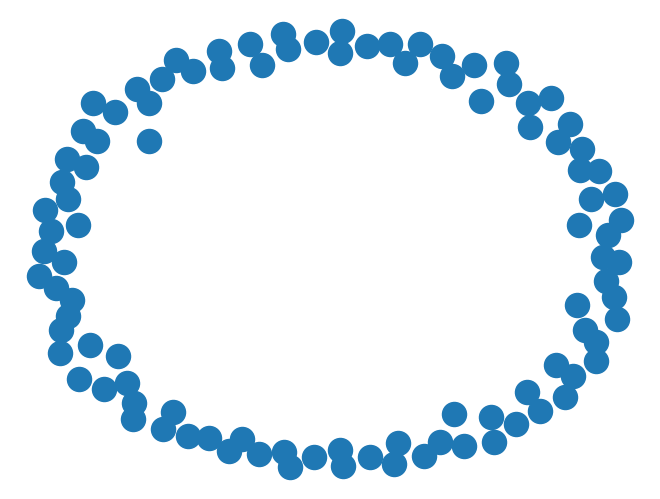

In [ ]:
import networkx as nx

G = nx.Graph()

# Add nodes using indices and store the atom data as a node attribute
for i, atom_data in enumerate(atoms):
    G.add_node(i, data=atom_data)

print(f"Number of nodes in the graph: {G.number_of_nodes()}")
print(f"Example node 0 data: {G.nodes[0]['data'].shape}")

nx.draw(G)

As the atoms are closely packed together, it is not able to be built into a Delaunay Triangulation at its current state.

### Advanced Graph Building

We seek to use PCA to reduce the dimensionality of the atoms into 2D space.

In [ ]:
from sklearn.decomposition import PCA

np.random.seed(42)
torch.manual_seed(42)
pca = PCA(n_components=2)
atoms_2d = pca.fit_transform(atoms)

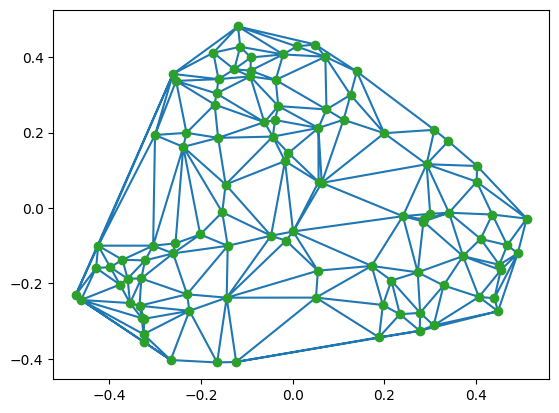

In [ ]:
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

np.random.seed(42)
torch.manual_seed(42)
delaunay = Delaunay(atoms_2d)

plt.triplot(atoms_2d[:, 0], atoms_2d[:, 1], delaunay.simplices.copy())
plt.plot(atoms_2d[:, 0], atoms_2d[:, 1], 'o')
plt.show()

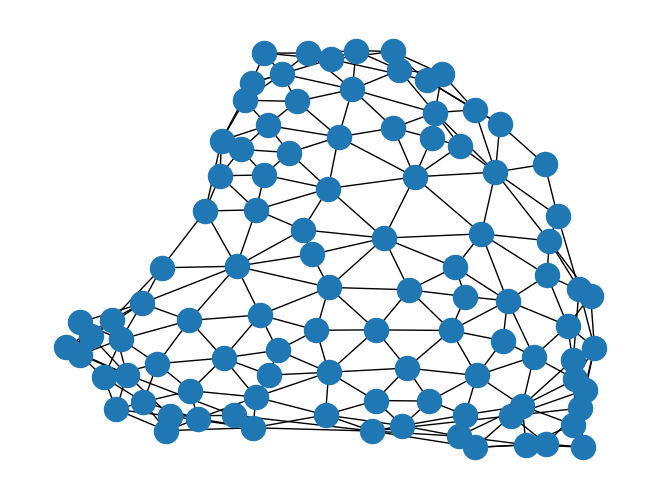

In [ ]:
np.random.seed(42)
torch.manual_seed(42)
G_delaunay = nx.Graph()

# Add nodes using indices and store the atom data as a node attribute
for i, atom_data in enumerate(atoms):
    G_delaunay.add_node(i, data=atom_data)

for simplex in delaunay.simplices:
    G_delaunay.add_edge(simplex[0], simplex[1])
    G_delaunay.add_edge(simplex[1], simplex[2])
    G_delaunay.add_edge(simplex[2], simplex[0])

nx.draw(G_delaunay)

(<Figure size 2000x2000 with 1 Axes>,
 <Axes: title={'center': 'Delaunay Graph with Dictionary Atoms as Images'}>)

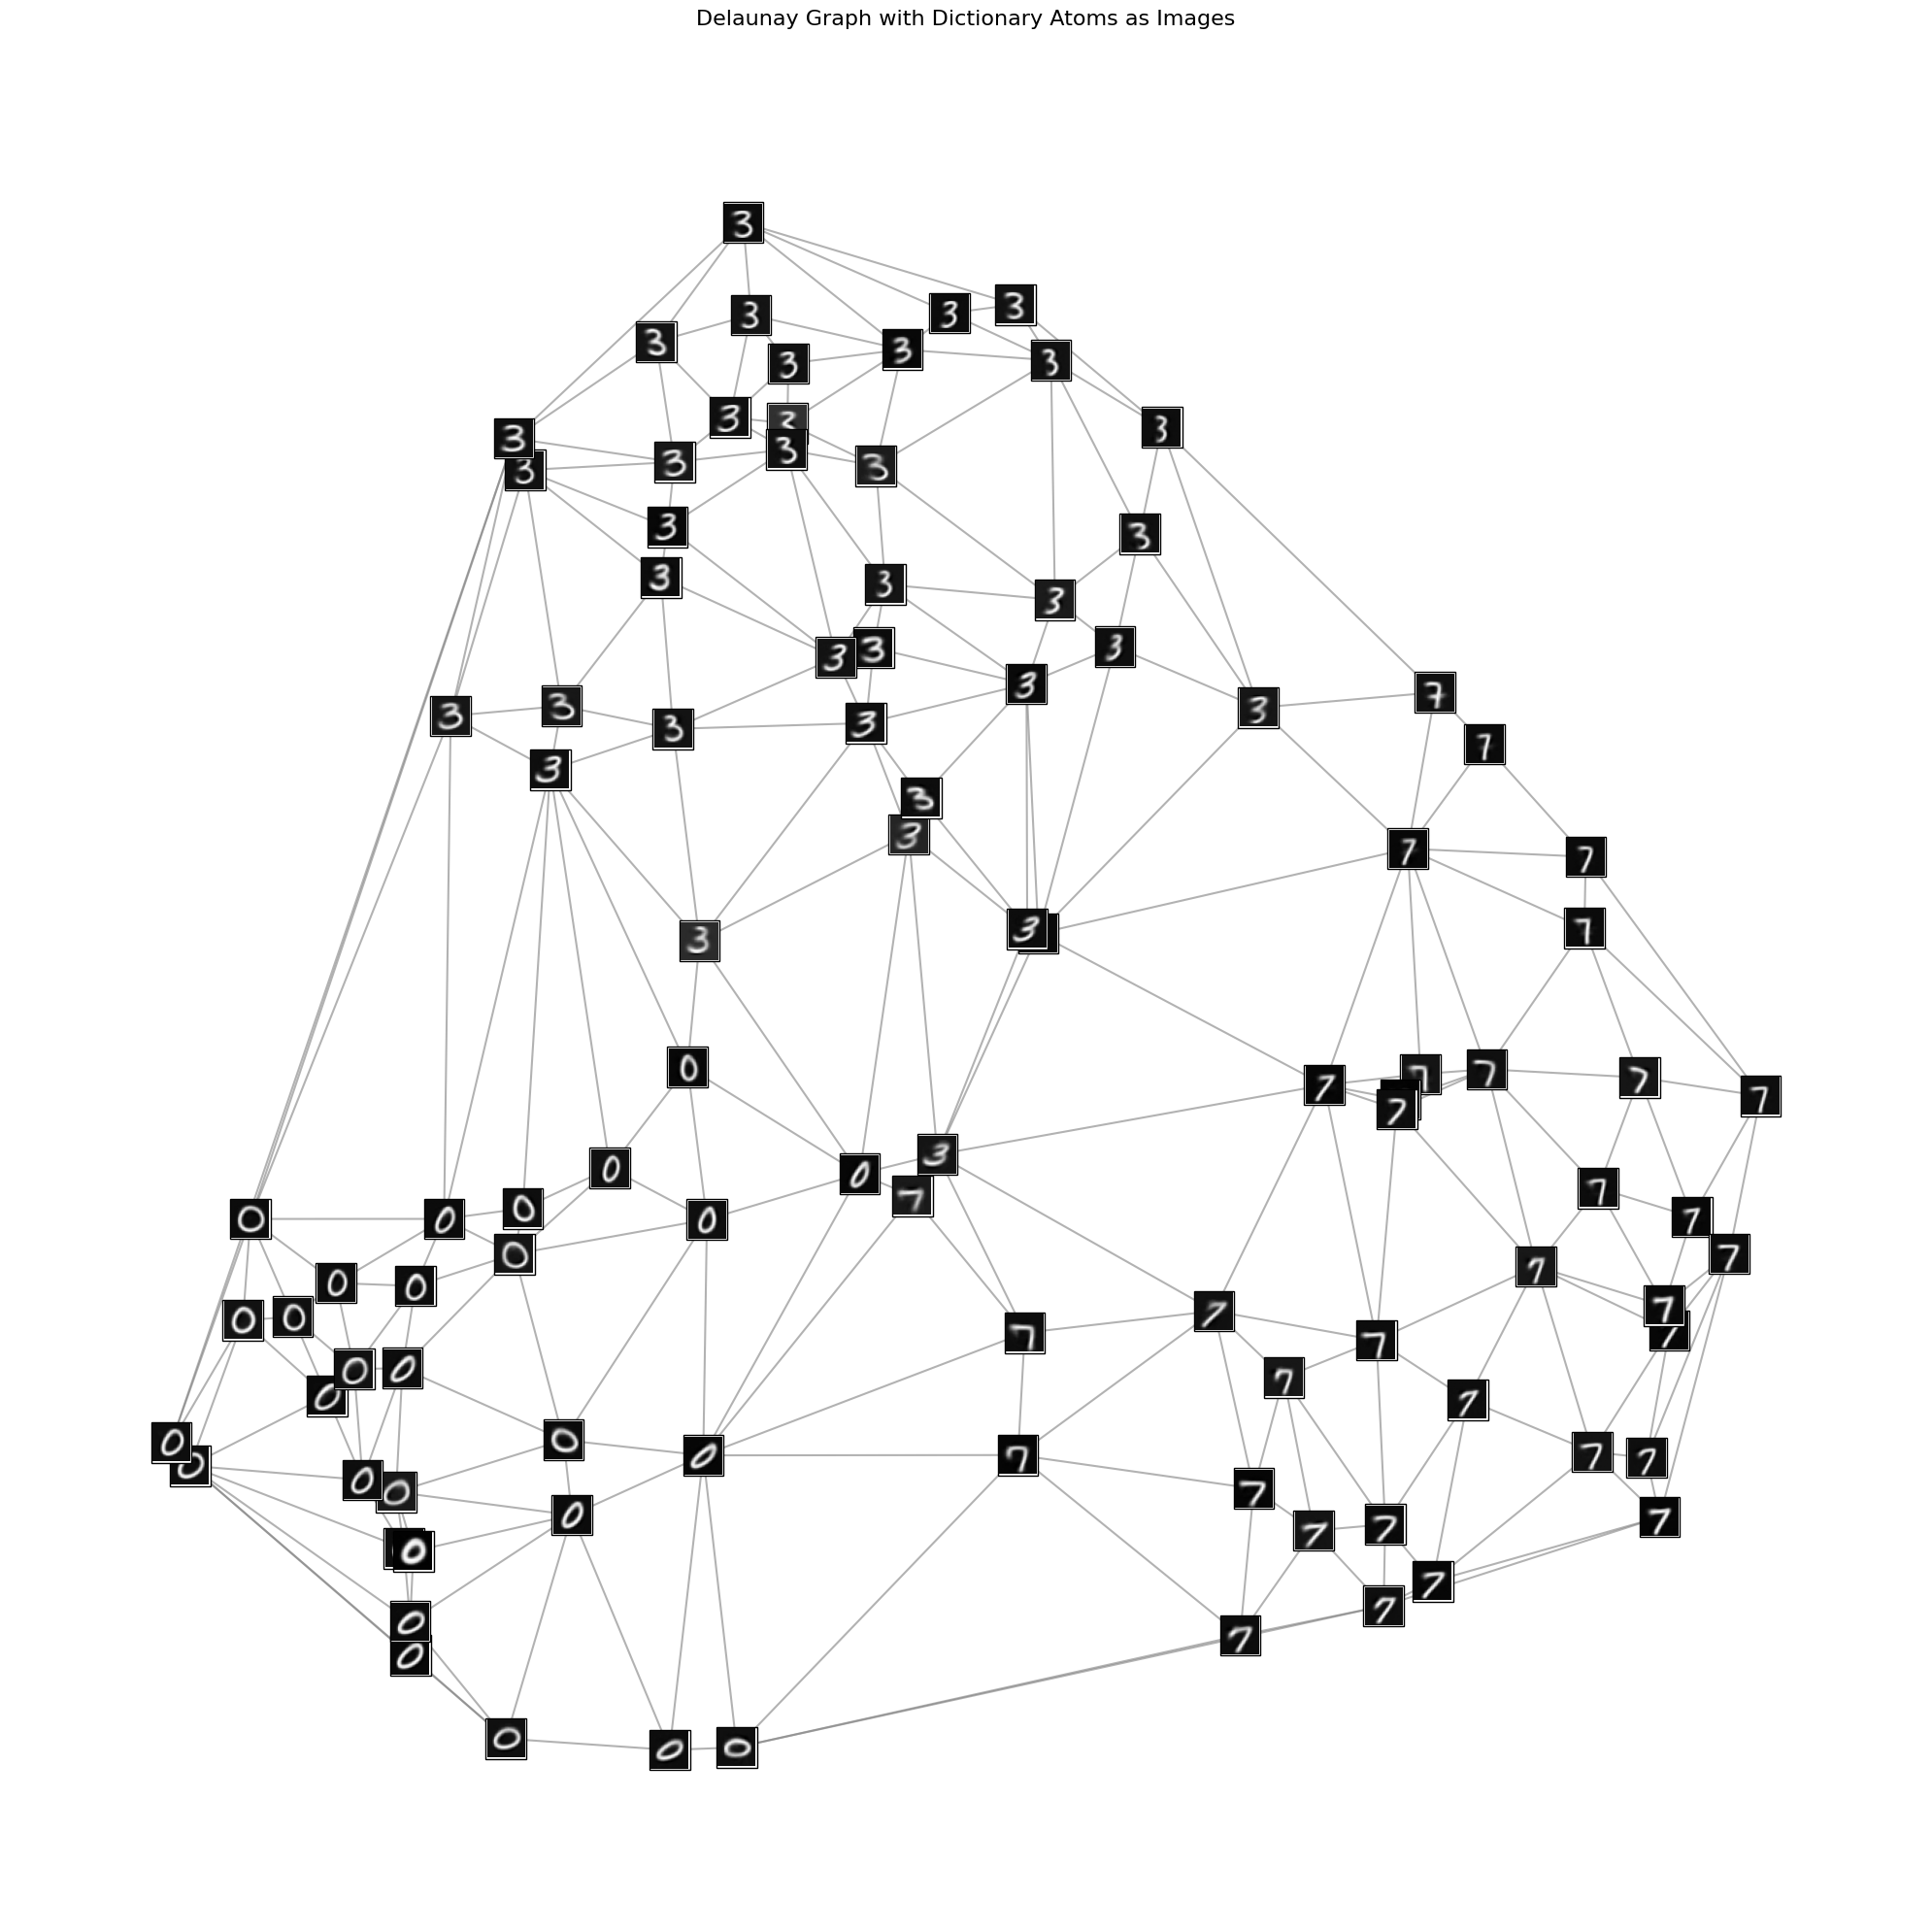

In [ ]:
# Using the coordinates of the 2D PCA projection
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from scipy.spatial import Delaunay

# Assume you have:
# - atoms: your dictionary atoms (100, 784) from net.W
# - delaunay: your Delaunay triangulation
# - G_delaunay: your NetworkX graph

# ============================================================================
# METHOD 1: Using OffsetImage and AnnotationBbox (RECOMMENDED)
# ============================================================================

# Adapted the code to use the PCA projected positions onto 2 Principal Components
def visualize_graph_with_images(G, atoms, positions, figsize=(20, 20), image_zoom=1):
    """
    Visualize graph where each node displays its corresponding atom image.

    Parameters:
    -----------
    G : NetworkX graph
        Graph with nodes corresponding to atom indices
    atoms : numpy array or torch tensor
        Dictionary atoms, shape (n_atoms, 784) for MNIST
    figsize : tuple
        Figure size
    image_zoom : float
        Scale factor for images (smaller = smaller images)
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Draw edges first (underneath the images)
    nx.draw_networkx_edges(G, positions, ax=ax, alpha=0.6, width=1.5, edge_color='gray')

    # Convert atoms to numpy if torch tensor
    if isinstance(atoms, torch.Tensor):
        atoms = atoms.detach().cpu().numpy()

    # Add each atom as an image at its node position
    for node_idx in G.nodes():
        # Get the atom data
        atom_data = atoms[node_idx].reshape(28, 28)

        # Create OffsetImage
        imagebox = OffsetImage(atom_data, zoom=image_zoom, cmap='gray')

        # Create AnnotationBbox at the node position
        ab = AnnotationBbox(imagebox, positions[node_idx],
                           frameon=True,
                           pad=0.1,
                           boxcoords="data")
        ax.add_artist(ab)

    ax.set_xlim([min(p[0] for p in positions) - 0.1,
                 max(p[0] for p in positions) + 0.1])
    ax.set_ylim([min(p[1] for p in positions) - 0.1,
                 max(p[1] for p in positions) + 0.1])
    ax.axis('off')
    plt.title('Delaunay Graph with Dictionary Atoms as Images', fontsize=16, pad=20)
    plt.tight_layout()
    return fig, ax

visualize_graph_with_images(G_delaunay, atoms, atoms_2d)

### Basic Graph Interpolation

In [ ]:
# For all the data points, express them as a convex combination of the learned dictionary W and sparse matrix X.
sparse_codes = torch.tensor(sparse_codes)
atoms = torch.tensor(atoms)
Y = torch.matmul(sparse_codes, atoms)
print(Y.shape)

torch.Size([18319, 784])


/tmp/ipython-input-4046156498.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sparse_codes = torch.tensor(sparse_codes)


In [ ]:
# Project data onto the 2D atoms to get their respective coordinates.
np.random.seed(42)
torch.manual_seed(42)
Y_2D = pca.transform(Y)
Y_2D = np.round(Y_2D, 2)

print(Y_2D)

[[-0.37 -0.24]
 [ 0.01  0.16]
 [-0.01  0.27]
 ...
 [-0.28 -0.3 ]
 [ 0.2  -0.21]
 [-0.1   0.2 ]]


(<Figure size 2000x2000 with 1 Axes>,
 <Axes: title={'center': 'Delaunay Graph with Dictionary Atoms as Images'}>)

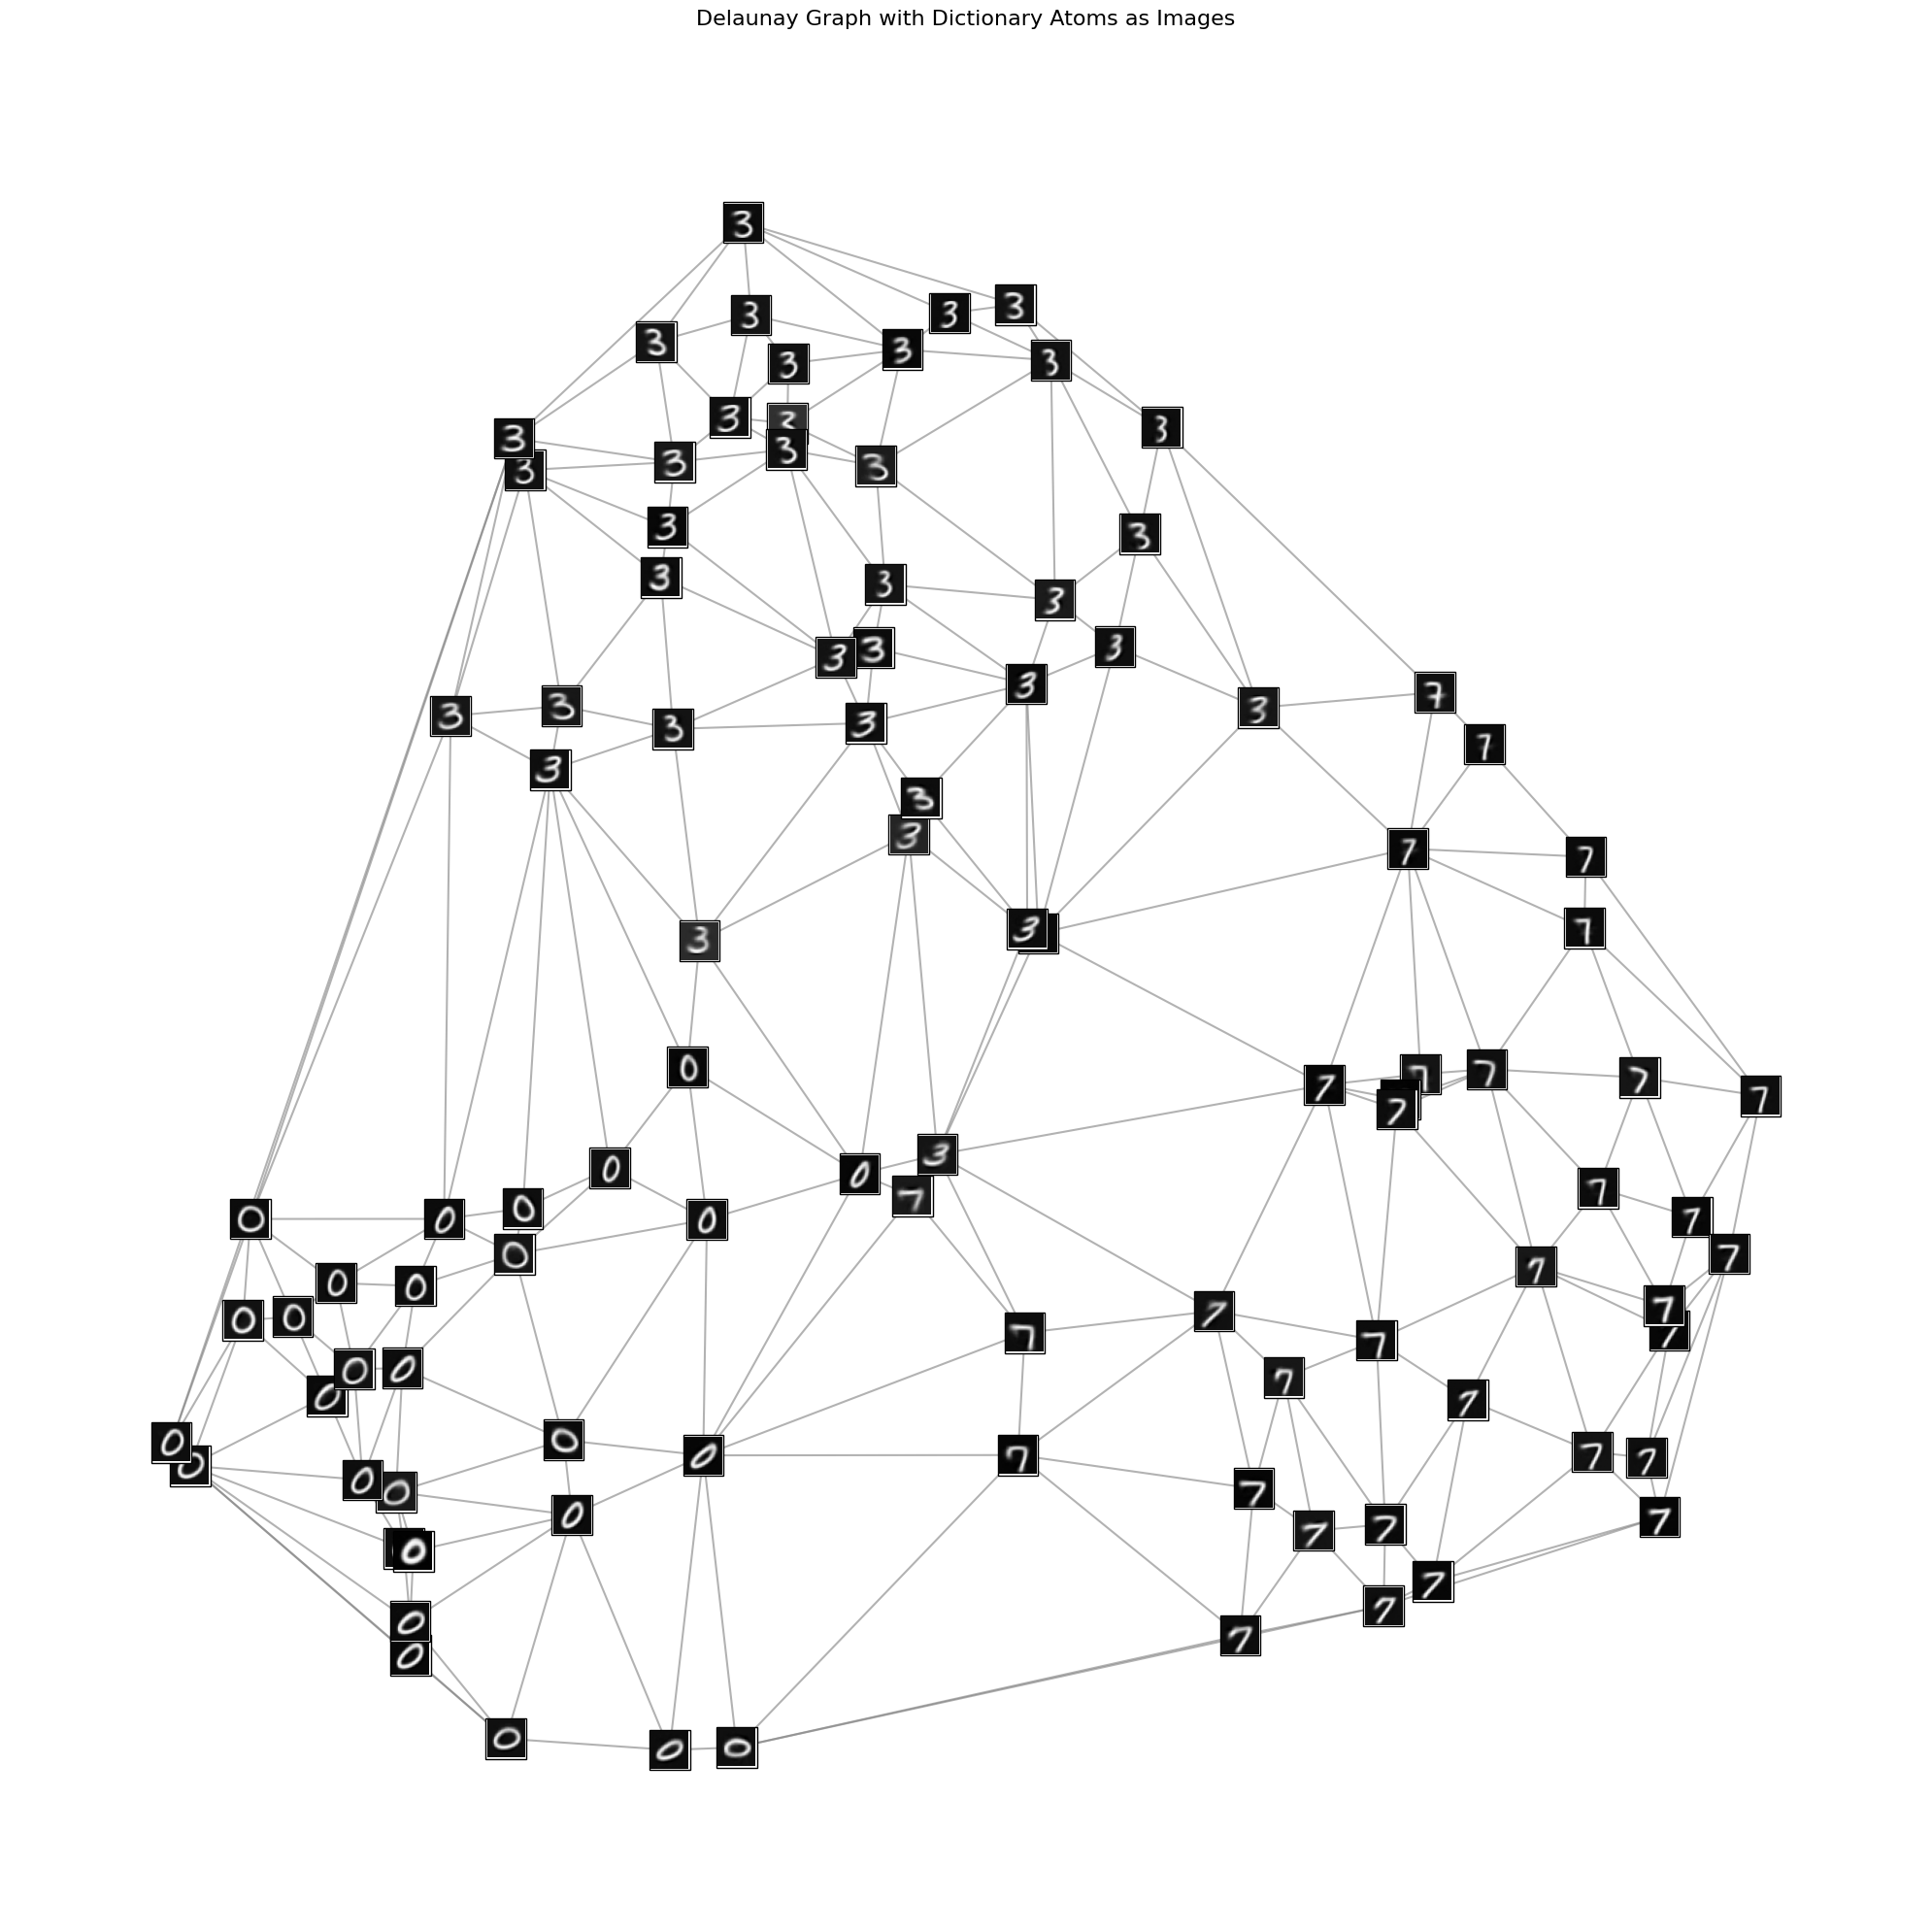

In [ ]:
visualize_graph_with_images(G_delaunay, atoms, atoms_2d)

Shape of KDS reconstructed images: (18319, 784)


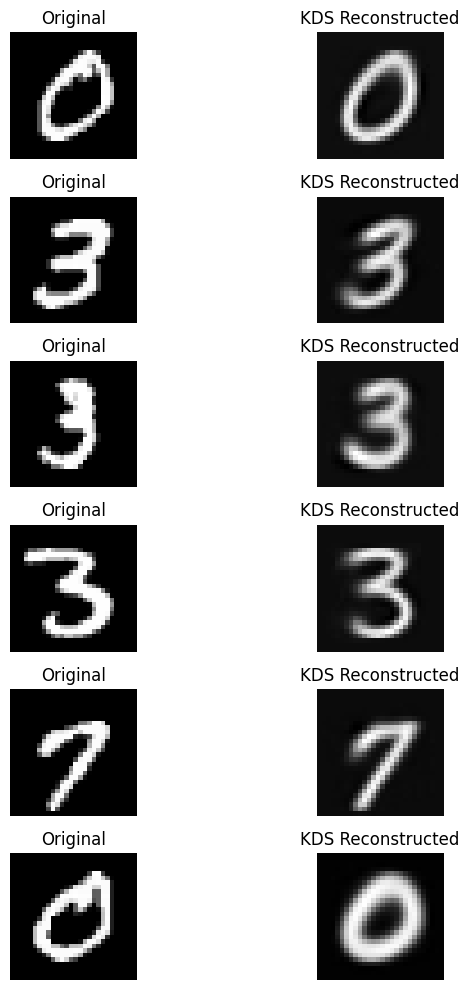

In [ ]:
n_images_to_display=6
with torch.no_grad():
  X_kds_reconstructed = net(X_filtered_tensor).detach().numpy()

print("Shape of KDS reconstructed images:", X_kds_reconstructed.shape)

# Reshape reconstructed data back to image dimensions for visualization
X_kds_reconstructed_images = X_kds_reconstructed.reshape(-1, 28, 28)

# Display some original and KDS reconstructed images
fig, axes = plt.subplots(n_images_to_display, 2, figsize=(8, 10))

for i in range(n_images_to_display):
    # Original image (need to convert back to numpy for matplotlib if X_filtered was modified)
    # Assuming X_filtered is still the original numpy array from previous cells
    axes[i, 0].imshow(X_filtered[i].reshape(28, 28), cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    # KDS reconstructed image
    axes[i, 1].imshow(X_kds_reconstructed_images[i], cmap='gray')
    axes[i, 1].set_title("KDS Reconstructed")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

(<Figure size 2000x2000 with 1 Axes>,
 <Axes: title={'center': 'Delaunay Graph with Dictionary Atoms as Images'}>)

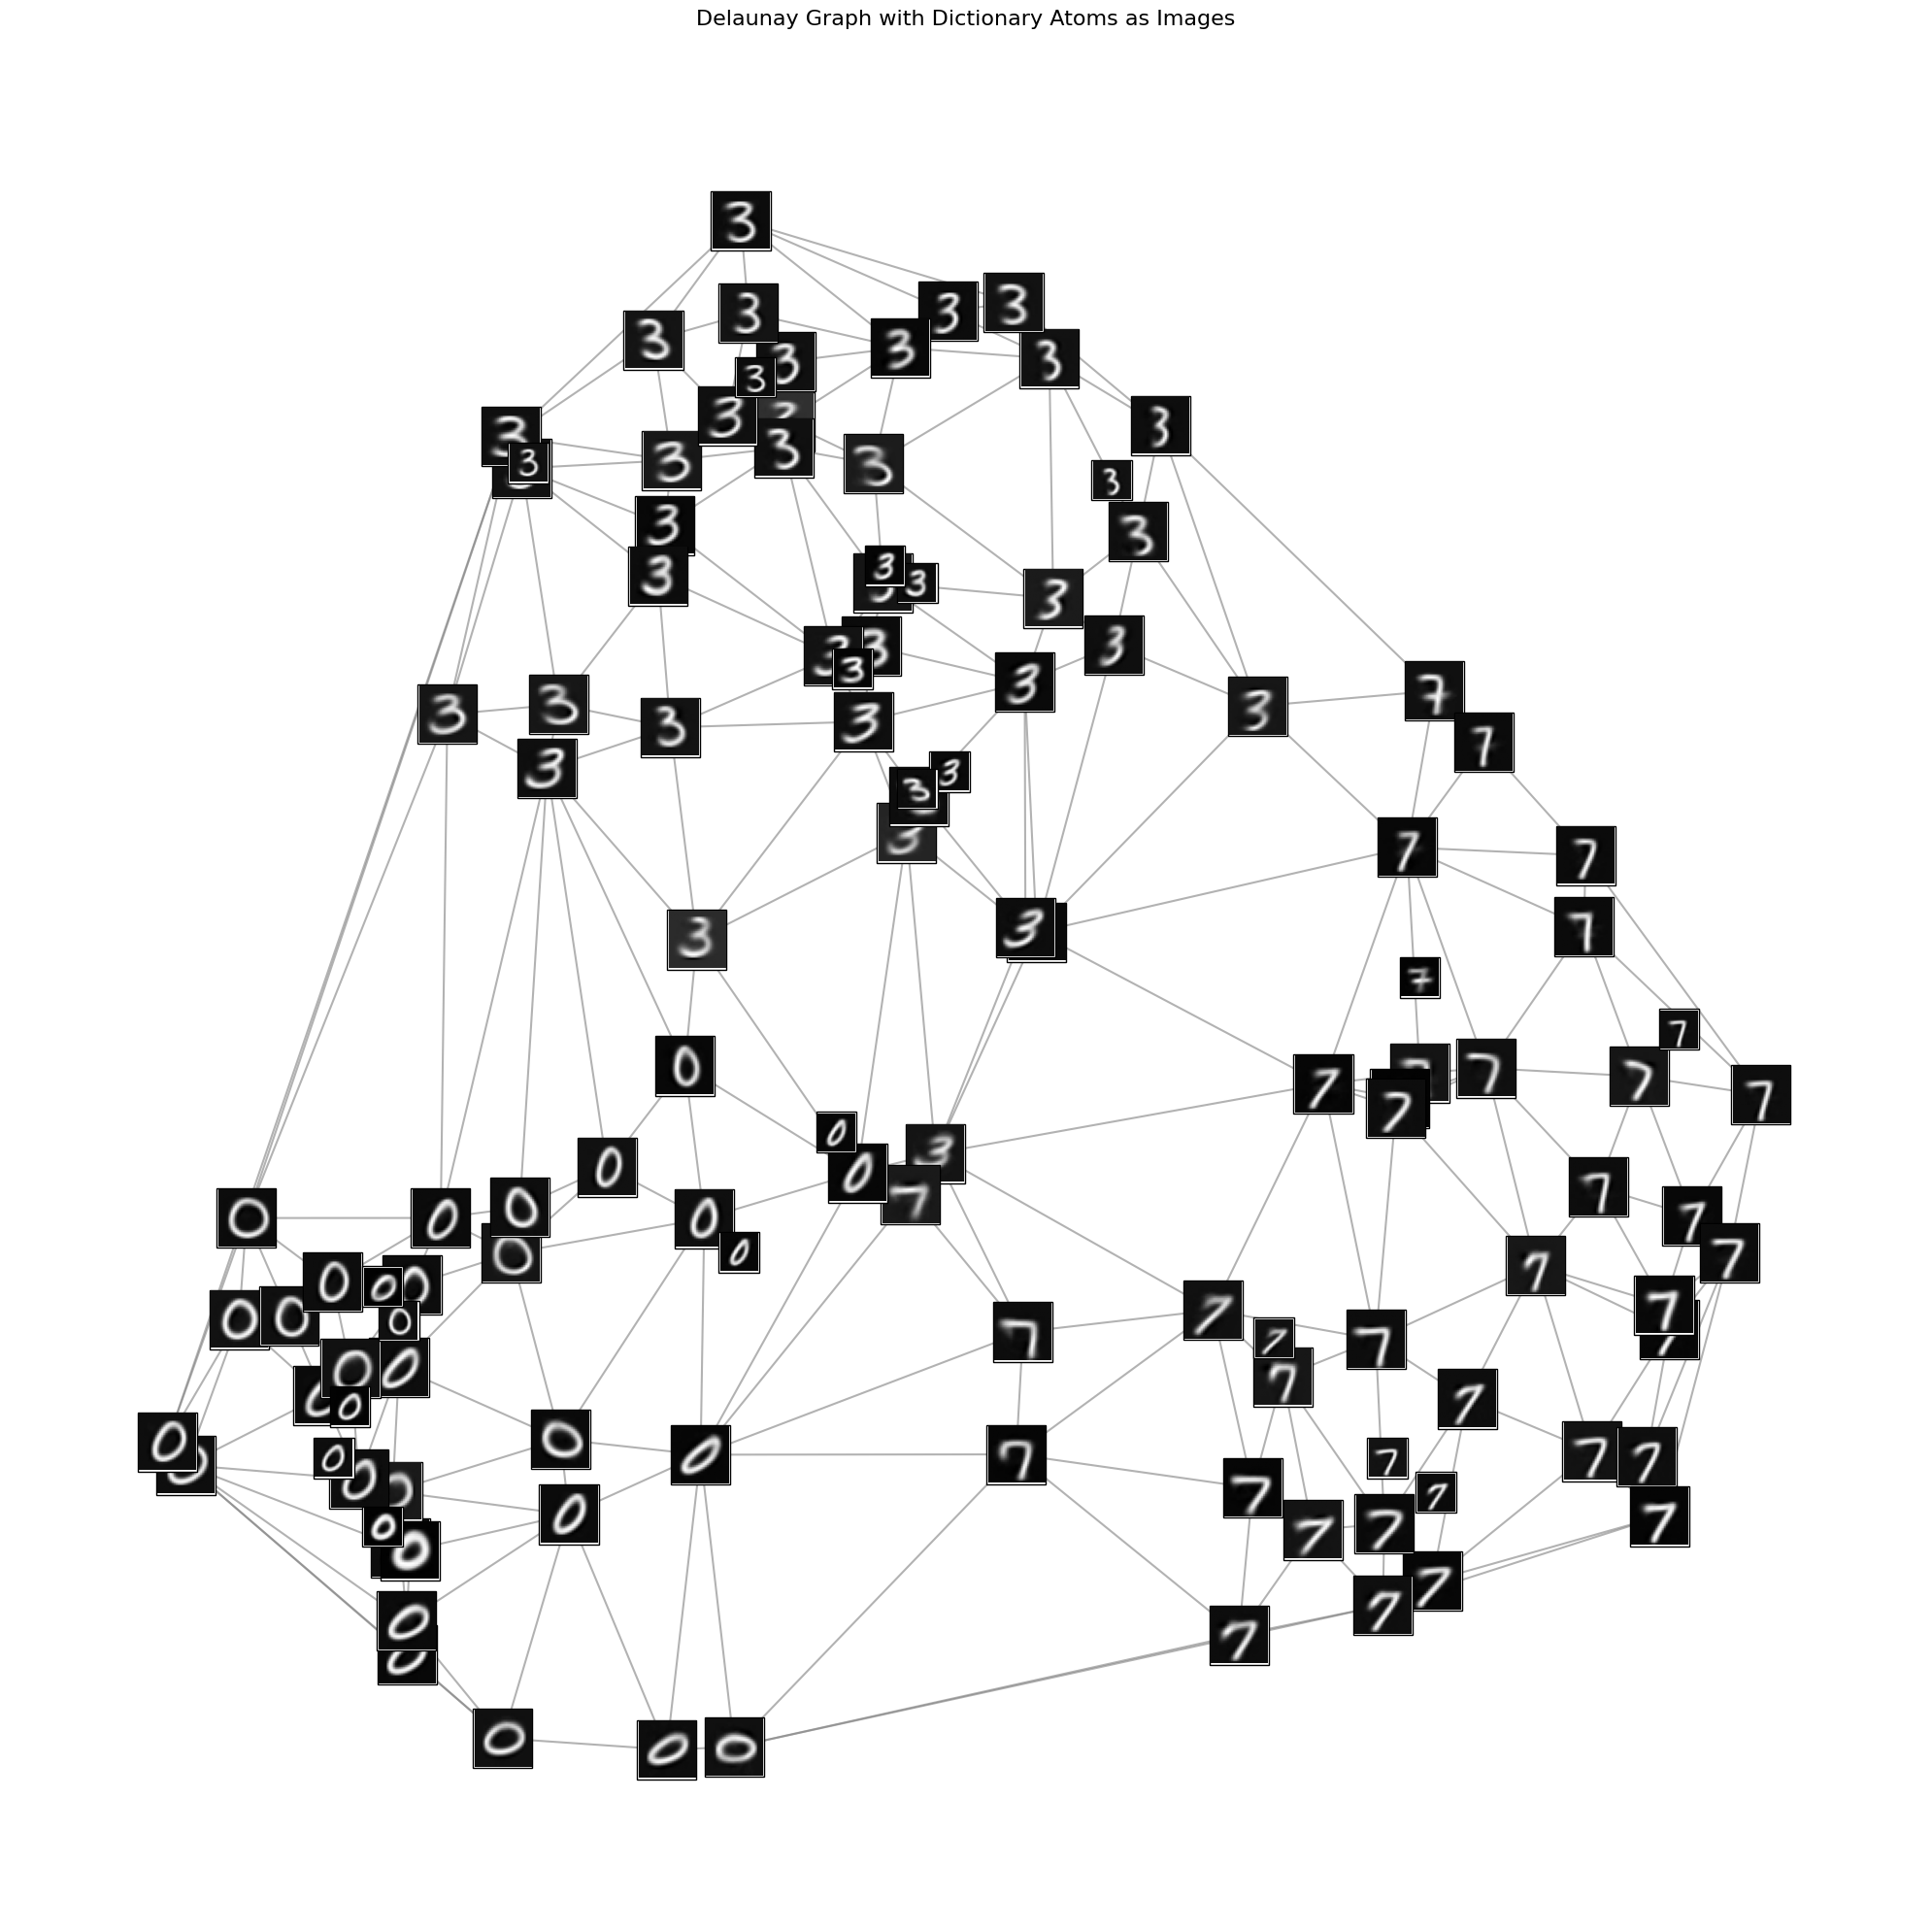

In [ ]:
# Adapted the code to use the PCA projected positions onto 2 Principal Components
def visualize_graph_with_data_points(G, positions_2D, atom_positions, reconstructed_images, figsize=(20, 20), image_zoom=1.5, image_zoom_recon = 1):
    """
    Visualize graph where each node displays its corresponding atom image.

    Parameters:
    -----------
    G : NetworkX graph
        Graph with nodes corresponding to atom indices
    atoms : numpy array or torch tensor
        Dictionary atoms, shape (n_atoms, 784) for MNIST
    figsize : tuple
        Figure size
    image_zoom : float
        Scale factor for images (smaller = smaller images)
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Draw edges first (underneath the images)
    nx.draw_networkx_edges(G, atom_positions, ax=ax, alpha=0.6, width=1.5, edge_color='gray')

    # Add each atom as an image at its node position
    for node_idx in G.nodes():
        # Get the atom data
        atom_data = atoms[node_idx].reshape(28, 28)

        # Create OffsetImage
        imagebox = OffsetImage(atom_data, zoom=image_zoom, cmap='gray')

        # Create AnnotationBbox at the node position
        ab = AnnotationBbox(imagebox, atom_positions[node_idx],
                           frameon=True,
                           pad=0.1,
                           boxcoords="data")
        ax.add_artist(ab)

    # Extract original image data, use 2D projected coordinates to position it in the Delaunay Triangulaton.
    for i in range(20):
        # Get the image data
        image_data = reconstructed_images[i].reshape(28, 28)

        # Create OffsetImage
        imagebox = OffsetImage(image_data, zoom=image_zoom_recon, cmap='gray')

        # Create AnnotationBbox at the node position
        ab = AnnotationBbox(imagebox, positions_2D[i],
                           frameon=True,
                           pad=0.1,
                           boxcoords="data")
        ax.add_artist(ab)

    ax.set_xlim([min(p[0] for p in positions_2D) - 0.1,
                 max(p[0] for p in positions_2D) + 0.1])
    ax.set_ylim([min(p[1] for p in positions_2D) - 0.1,
                 max(p[1] for p in positions_2D) + 0.1])
    ax.axis('off')
    plt.title('Delaunay Graph with Dictionary Atoms as Images', fontsize=16, pad=20)
    plt.tight_layout()
    return fig, ax

visualize_graph_with_data_points(G=G_delaunay, positions_2D=Y_2D, atom_positions=atoms_2d, reconstructed_images=X_kds_reconstructed_images)

### Selecting two data points at random

In [ ]:
# Pick two data points at random, perform interpolation metrics.
np.random.seed(42)
two_indices=np.random.choice(range(20), size=2, replace=False)
print(two_indices)

A = X_kds_reconstructed_images[two_indices[0]]
B = X_kds_reconstructed_images[two_indices[1]]

pos_A = Y_2D[two_indices[0]]
pos_B = Y_2D[two_indices[1]]

print(pos_A)
print(pos_B)

[ 0 17]
[-0.37 -0.24]
[ 0.28 -0.24]


(<Figure size 2000x2000 with 1 Axes>,
 <Axes: title={'center': 'Delaunay Graph with Dictionary Atoms as Images'}>)

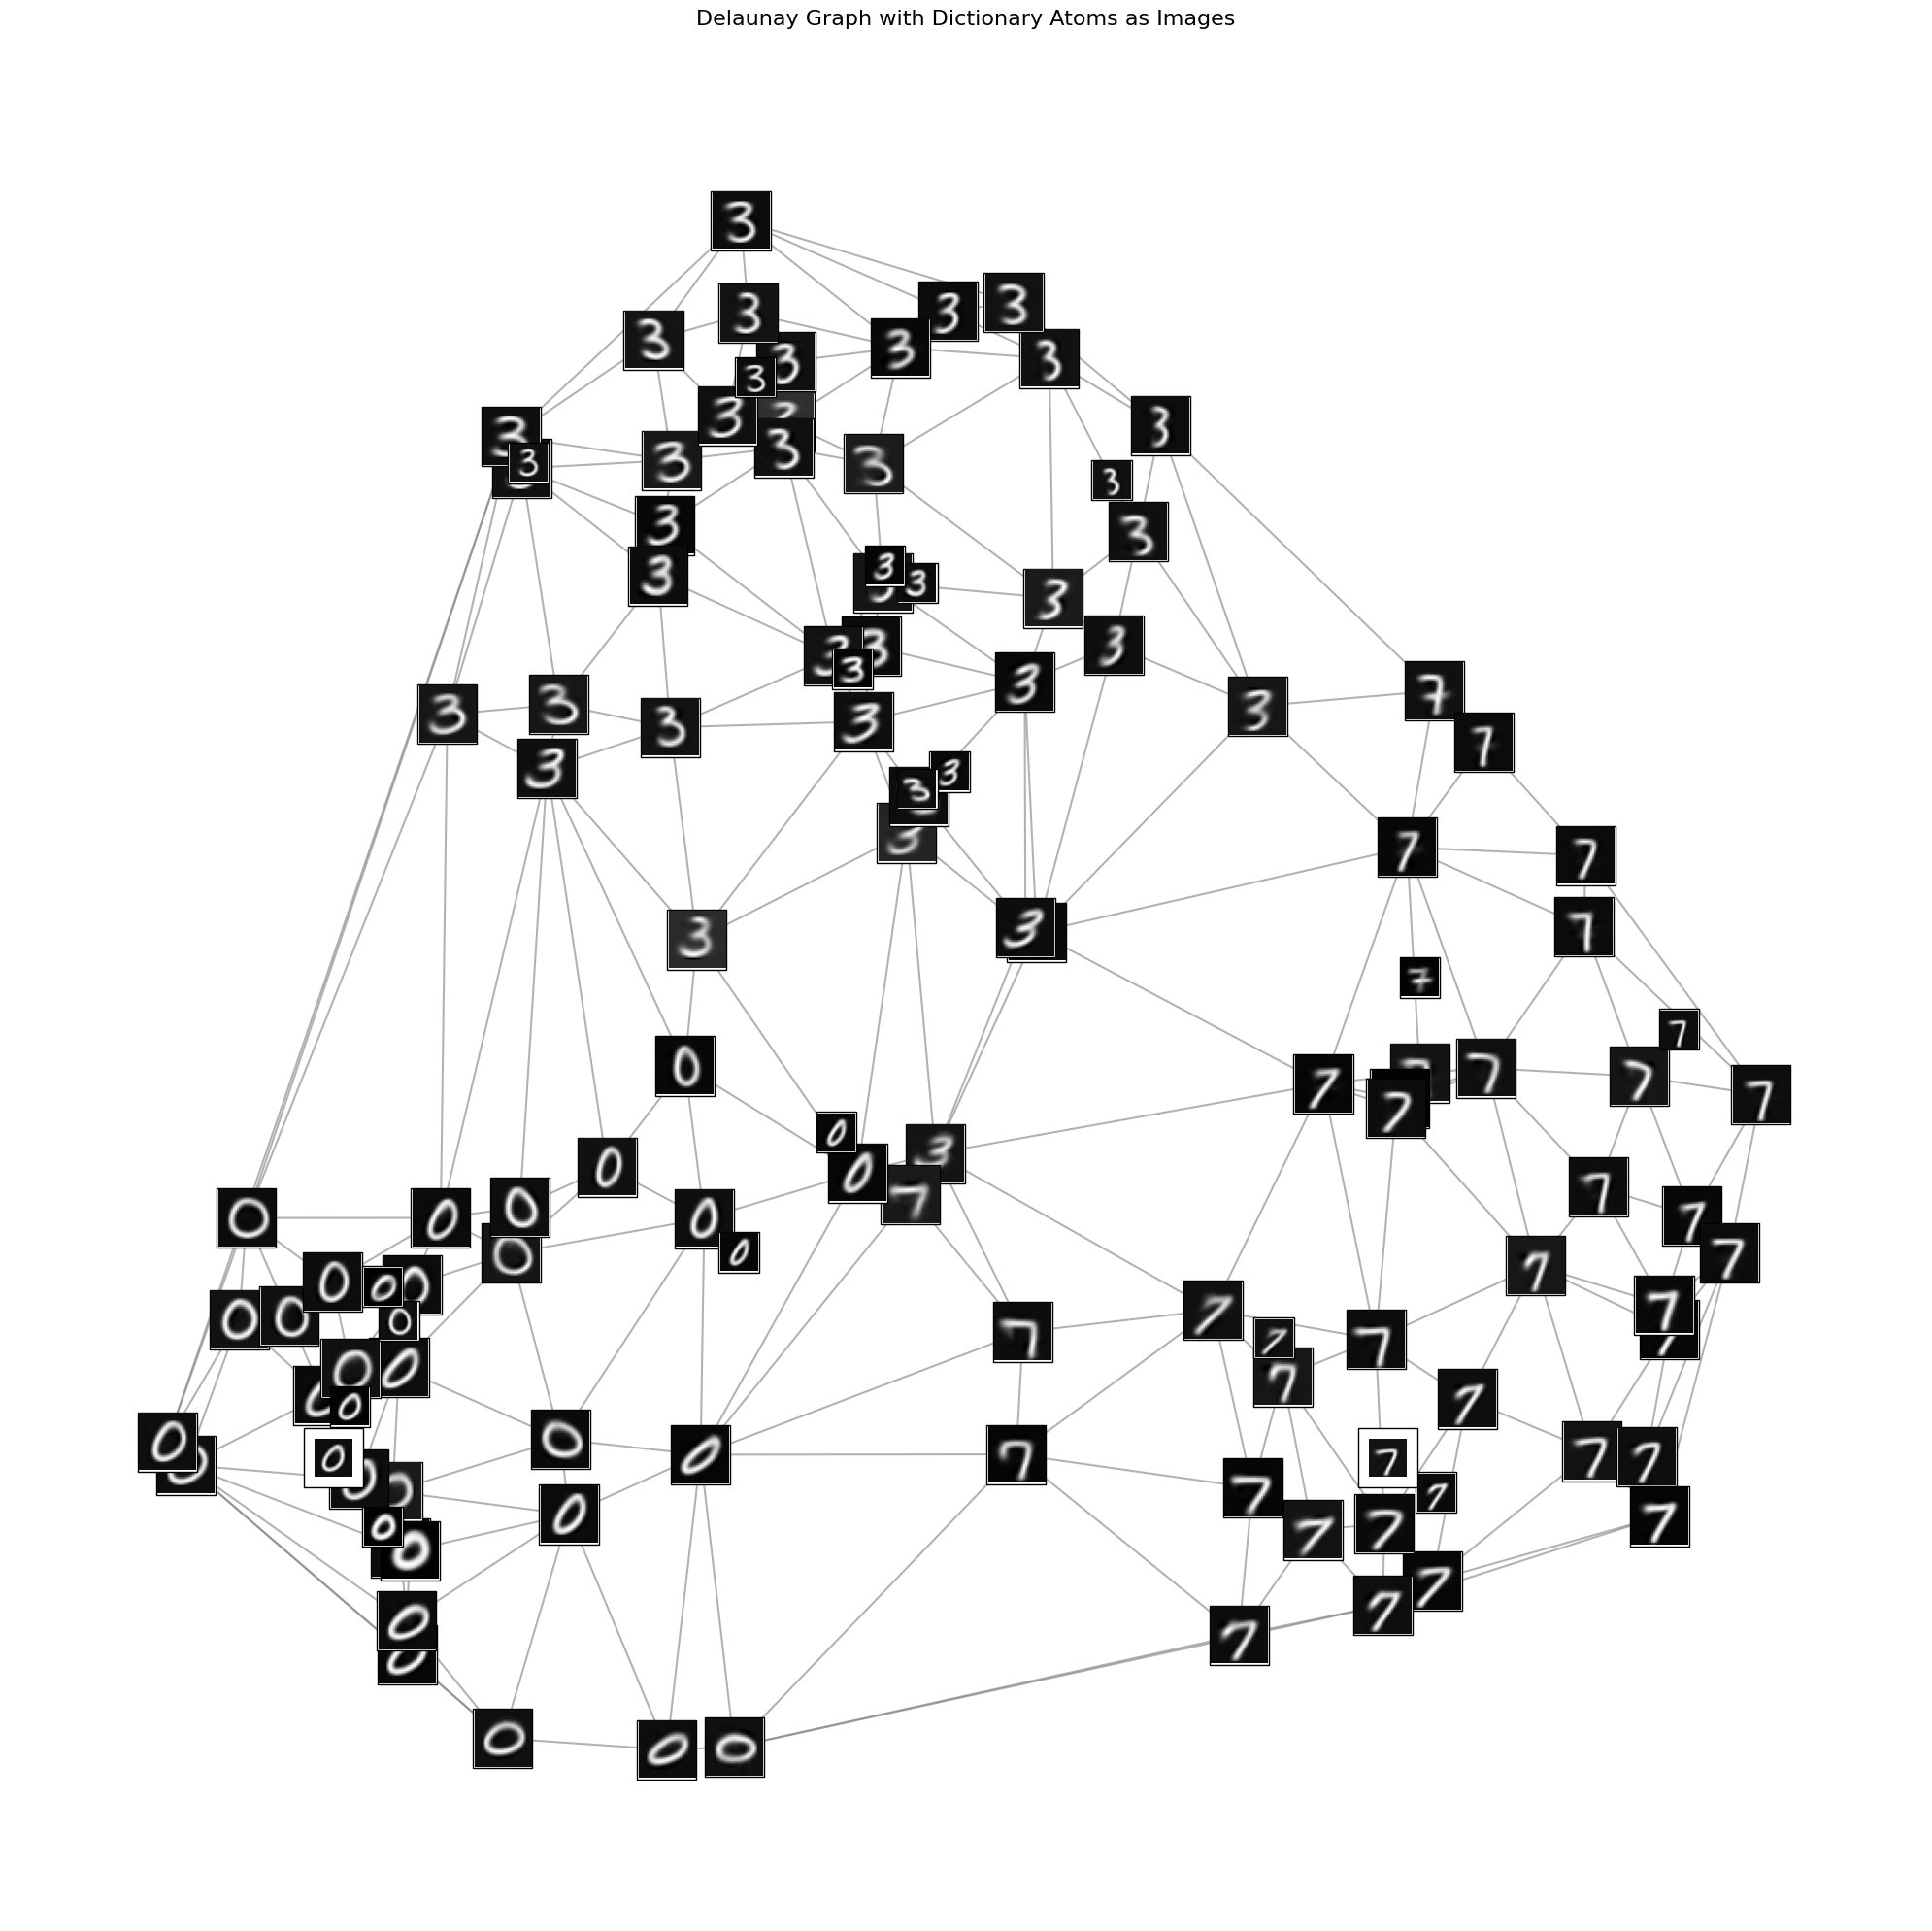

In [ ]:
# Adapted the code to use the PCA projected positions onto 2 Principal Components
def visualize_graph_with_data_and_start_end_points(G, positions_2D, atom_positions, reconstructed_images, indices, figsize=(20, 20), image_zoom=1.5, image_zoom_recon = 1):
    """
    Visualize graph where each node displays its corresponding atom image.

    Parameters:
    -----------
    G : NetworkX graph
        Graph with nodes corresponding to atom indices
    atoms : numpy array or torch tensor
        Dictionary atoms, shape (n_atoms, 784) for MNIST
    figsize : tuple
        Figure size
    image_zoom : float
        Scale factor for images (smaller = smaller images)
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Draw edges first (underneath the images)
    nx.draw_networkx_edges(G, atom_positions, ax=ax, alpha=0.6, width=1.5, edge_color='gray')

    # Add each atom as an image at its node position
    for node_idx in G.nodes():
        # Get the atom data
        atom_data = atoms[node_idx].reshape(28, 28)

        # Create OffsetImage
        imagebox = OffsetImage(atom_data, zoom=image_zoom, cmap='gray')

        # Create AnnotationBbox at the node position
        ab = AnnotationBbox(imagebox, atom_positions[node_idx],
                           frameon=True,
                           pad=0.1,
                           boxcoords="data")
        ax.add_artist(ab)

    # Extract original image data, use 2D projected coordinates to position it in the Delaunay Triangulaton.
    for i in range(20):
        # Get the image data
        image_data = reconstructed_images[i].reshape(28, 28)

        # Create OffsetImage
        imagebox = OffsetImage(image_data, zoom=image_zoom_recon, cmap='gray')

        # Create AnnotationBbox at the node position
        ab = AnnotationBbox(imagebox, positions_2D[i],
                           frameon=True,
                           pad=0.1 if i not in indices else 0.8,
                           boxcoords="data")
        ax.add_artist(ab)

    ax.set_xlim([min(p[0] for p in positions_2D) - 0.1,
                 max(p[0] for p in positions_2D) + 0.1])
    ax.set_ylim([min(p[1] for p in positions_2D) - 0.1,
                 max(p[1] for p in positions_2D) + 0.1])
    ax.axis('off')
    plt.title('Delaunay Graph with Dictionary Atoms as Images', fontsize=16, pad=20)
    plt.tight_layout()
    return fig, ax

visualize_graph_with_data_and_start_end_points(G=G_delaunay, positions_2D=Y_2D, atom_positions=atoms_2d, reconstructed_images=X_kds_reconstructed_images, indices=two_indices)

### Graph Interpolation Demo

In [ ]:
'''
Now that we have gotten the atoms, I would like to define the weights of
the edges to be the the differences of the atoms sparse codes.

Step 1: Go through all of the of atoms.
Step 2: The computed edge weight is the difference of the sparse codes.
'''
for node_idx in G_delaunay.nodes():
  print(f'Current node index: {node_idx}')
  # No gradient influence throughout the encoding step to get the sparse codes.
  with torch.no_grad():
    cur_atom = net.encode(atoms[node_idx].unsqueeze(0)) # Access the current atom sparse codes.
    sparse_code_node = cur_atom # Assign encoded result into the sparse_code_node variable
    # For each connection, calculate the difference between the sparse codes.
    for connection in G_delaunay.edges(node_idx):
      print(f'Current connection for cur node idx {node_idx} - {connection[1]}')
      edge = sparse_code_node - net.encode(atoms[connection[1]].unsqueeze(0)) # connection: [source_node, target_node]
      edge_norm = torch.norm(edge)
      G_delaunay.add_weighted_edges_from([(node_idx, connection[1], edge)])
      print(f'Current edge weight: {edge_norm}')




Current node index: 0
Current connection for cur node idx 0 - 38
Current edge weight: 1.4142135381698608
Current connection for cur node idx 0 - 55
Current edge weight: 1.4142135381698608
Current connection for cur node idx 0 - 39
Current edge weight: 1.4142135381698608
Current node index: 1
Current connection for cur node idx 1 - 91
Current edge weight: 1.4142135381698608
Current connection for cur node idx 1 - 29
Current edge weight: 1.4142135381698608
Current connection for cur node idx 1 - 68
Current edge weight: 1.4142135381698608
Current connection for cur node idx 1 - 5
Current edge weight: 1.4142135381698608
Current connection for cur node idx 1 - 2
Current edge weight: 1.4142135381698608
Current connection for cur node idx 1 - 12
Current edge weight: 1.4142135381698608
Current connection for cur node idx 1 - 83
Current edge weight: 1.4142135381698608
Current connection for cur node idx 1 - 71
Current edge weight: 1.4142135381698608
Current node index: 2
Current connection for 

In [ ]:
# For the first twenty data points, get the convex combination of the atoms it's local to.
for i in range(10, 20):
  print(f'Current index - {i}')
  cur_data = X_kds_reconstructed_images[i].reshape(1, 784)
  cur_data = torch.tensor(cur_data)
  with torch.no_grad():
    sparse_codes = net.encode(cur_data)
    print(f'Current sparse codes shape: {sparse_codes.shape}')
    print(f'Current sparse codes: {sparse_codes}')

Current index - 10
Current sparse codes shape: torch.Size([1, 100])
Current sparse codes: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0607, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0626, 0.0000, 0.0000, 0.8767, 0.0000, 0.0000, 0.0000,
         0.0000]])


### Notes

1. Introduce the t parameter from the KDS model
2. Look into the Github, run the model with the parameters used in the MNIST data.
3.